In [1]:
#Imports
import matplotlib.pyplot as plt
import pandas as pd
from Span_dist_alpha import alpha_span_dist
from Span_dist_forces import forces_span_dist
from Span_dist_inductions import induction_span_dist
from Total_forces_vs_J import forces_vs_J
from Convergence_history import Convergence_history
import numpy as np

U0 = 60
rho  = 1.007
d = 0.7*2

In [2]:
# Our code total results
#validation data path
df = pd.read_csv('Validation_DAta/results_Varying_J_val.csv')
# df = pd.read_csv('Validation_DAta/old_res_val.csv')
#Normal data path
# df = pd.read_csv('results_Varying_J.csv')
Pc = df["Total Power"] / (rho * U0**3 * (0.7*2)**2)
df["eta_harv"] = -Pc * 8/np.pi

# print(df.head())


# dfEXPres

In [3]:
#Java Prop validation data for whole propeller
csv_file_path = 'JavaPropValMulti.csv'
dfs = pd.read_csv(csv_file_path, sep=r"\s+")
dfs = dfs.drop([0]) #drop the second row
dfs = dfs.rename(columns={'v/(nD)': 'J', 'v':'V','?':'eta', '?*':'eta*', "Ct":"CT", "Cp":"CP"}) #rename columns
dfs = dfs.drop(columns=["v/(?R)","Cs","eta*","stalled"],axis=1) #drop
dfs = dfs.astype(float) #convert all columns to float
dfs = dfs[dfs['J'] > 1.2]
dfs['CQ'] = dfs['Torque'] / dfs['Thrust'] * dfs['CT']/d  # Convert to kN-m
dfs['eta'] = dfs['eta']/100
dfJavawhole = dfs


In [4]:
#Java prop spanwise results
csv_file_path = 'JavaPropValSingle.csv'
dfs = pd.read_csv(csv_file_path, sep=r"\s+")
dfs = dfs.astype(float) #convert all columns to float
dfs = dfs.rename(columns={'r/R': 'r_R' ,"a'": "a_prime"}) #rename columns
dfs = dfs.drop(columns=["dCT/d(r/R)",	"dCP/d(r/R)",	"?",	"?*",	"?ff",	"?Vax/V",	"?Vtan/V"	,"CQx"	,"CMx"	,"CQy"	,"CMy"],axis=1) #drop
dfs['beta'] = -50*dfs['r_R']+35 + 46
dfs["inflow"] = dfs["beta"] - dfs["alpha"]
# print(dfs.head())
dfJavaSing = dfs



In [5]:
#Our spanwise results
#Validation data path
csv_file_path = ('Validation_DAta/Propeller_radial_data_val.csv')
#Normal data path
# csv_file_path = 'Propeller_radial_data.csv'
dfs = pd.read_csv(csv_file_path, sep=r",")
# print(dfs.head())
dfSing = dfs

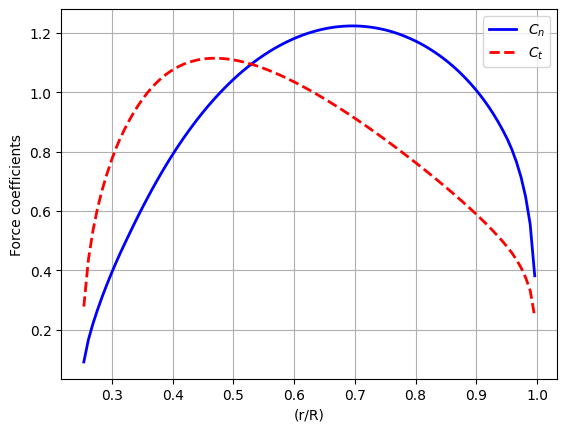

In [6]:
forces_span_dist(exp_df=dfSing,save=True)

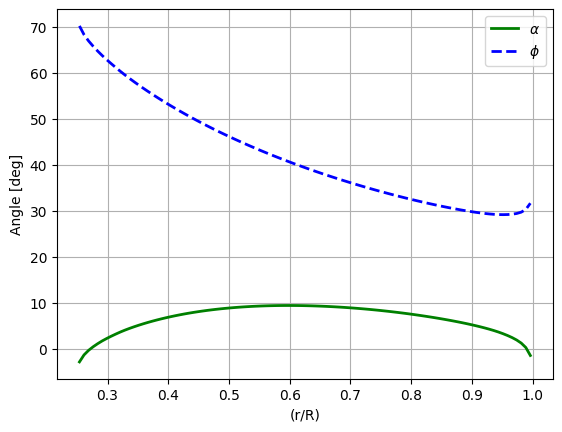

In [7]:
alpha_span_dist(exp_df=dfSing,save=True)

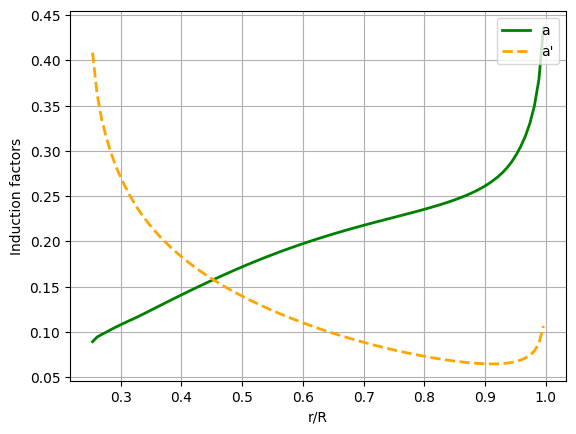

In [11]:
induction_span_dist(exp_df=dfSing,save=True)

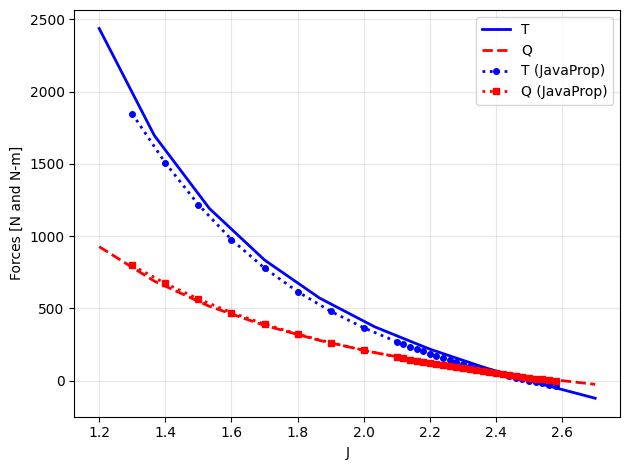

In [9]:
forces_vs_J(exp_df=df, val_df=dfJavawhole,save=True)

1036.4773344829946


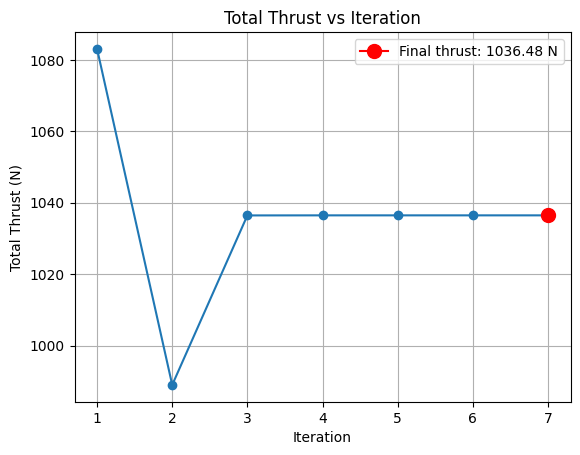